Lung Cancer detection using CT scan Images

In [19]:
import os
import shutil
import random
from collections import Counter
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
from tensorflow.keras.applications import ResNet50, VGG16, EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

In [2]:
train_dir = "/content/drive/MyDrive/Lung cancer CT scan img/train"
val_dir = "/content/drive/MyDrive/Lung cancer CT scan img/valid"
test_dir ="/content/drive/MyDrive/Lung cancer CT scan img/test"

In [4]:
# Check class distribution
# ============================
def count_images(folder):
    counts = {}
    for cls in os.listdir(folder):
        cls_path = os.path.join(folder, cls)
        if os.path.isdir(cls_path):
            counts[cls] = len(os.listdir(cls_path))
    return counts

print("Train distribution before balancing:", count_images(train_dir))
print("Val distribution:", count_images(val_dir))
print("Test distribution:", count_images(test_dir))

Train distribution before balancing: {'A': 195, 'N': 148, 'L': 115, 'S': 155}
Val distribution: {'A': 23, 'L': 21, 'N': 13, 'S': 15}
Test distribution: {'S': 90, 'N': 54, 'L': 51, 'A': 120}


In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
# Augmentation setup
# ============================
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# ============================
# Balance training dataset
# ============================
def balance_train_dataset(folder):
    counts = count_images(folder)
    target_count = max(counts.values())  # balance to the largest class
    print(f"Target count per class: {target_count}")

    for cls in os.listdir(folder):
        cls_path = os.path.join(folder, cls)
        if not os.path.isdir(cls_path):
            continue

        images = os.listdir(cls_path)
        current_count = len(images)
        print(f"\nClass {cls}: {current_count} images")

        if current_count >= target_count:
            print(f"--> Skipping {cls}, already has enough images")
            continue

        # Augment images
        i = 0
        while len(os.listdir(cls_path)) < target_count:
            img_name = np.random.choice(images)
            img_path = os.path.join(cls_path, img_name)

            try:
                img = load_img(img_path, target_size=(128, 128))
                x = img_to_array(img)
                x = np.expand_dims(x, axis=0)

                aug_iter = datagen.flow(x, batch_size=1, save_to_dir=cls_path,
                                        save_prefix='aug', save_format='jpg')
                next(aug_iter)  # generate one image
                i += 1
            except Exception as e:
                print(f"Skipping {img_name} due to error: {e}")

# Balance only training set
balance_train_dataset(train_dir)

print("\nTrain distribution after balancing:", count_images(train_dir))

Target count per class: 195

Class A: 195 images
--> Skipping A, already has enough images

Class N: 148 images

Class L: 115 images

Class S: 155 images

Train distribution after balancing: {'A': 195, 'N': 195, 'L': 195, 'S': 195}


In [11]:
def increase_test_dataset(folder, target_count=100):
    for cls in os.listdir(folder):
        cls_path = os.path.join(folder, cls)
        if not os.path.isdir(cls_path):
            continue

        images = os.listdir(cls_path)
        current_count = len(images)

        if current_count >= target_count:
            print(f"Class {cls}: Already at or above target count ({current_count})")
            continue

        # Number of images needed
        needed = target_count - current_count
        print(f"Class {cls}: Need to add {needed} images")

        for i in range(needed):
            img_name = random.choice(images)
            src = os.path.join(cls_path, img_name)
            dst = os.path.join(cls_path, f"dup_{i}_{img_name}")
            shutil.copy(src, dst)

        print(f"Class {cls} after increase: {len(os.listdir(cls_path))} images")

# Usage
increase_test_dataset(test_dir, target_count=700)

# Check distribution
def count_images(folder):
    counts = {}
    for cls in os.listdir(folder):
        cls_path = os.path.join(folder, cls)
        if os.path.isdir(cls_path):
            counts[cls] = len(os.listdir(cls_path))
    return counts

print("Test distribution after increase:", count_images(test_dir))

Class S: Need to add 610 images
Class S after increase: 700 images
Class N: Need to add 646 images
Class N after increase: 700 images
Class L: Need to add 649 images
Class L after increase: 700 images
Class A: Need to add 580 images
Class A after increase: 700 images
Test distribution after increase: {'S': 700, 'N': 700, 'L': 700, 'A': 700}


In [13]:
# Data Generators
# ============================
train_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    train_dir, target_size=(224,224), batch_size=32, class_mode='categorical')

val_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    val_dir, target_size=(224,224), batch_size=32, class_mode='categorical')

test_gen = ImageDataGenerator(rescale=1./255).flow_from_directory(
    test_dir, target_size=(224,224), batch_size=32, class_mode='categorical', shuffle=False)


Found 780 images belonging to 4 classes.
Found 72 images belonging to 4 classes.
Found 2800 images belonging to 4 classes.


In [33]:
# Step 5: Build the CNN Model
from tensorflow.keras import models, layers, optimizers, callbacks

# Model Architecture
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax') ])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [35]:
history = model.fit(
    train_gen,
    steps_per_epoch=len(train_gen),
    validation_data=val_gen,
    validation_steps=len(val_gen),
    epochs=20, )

Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 163s 7s/step - accuracy: 0.4918 - loss: 13.8861 - val_accuracy: 0.3194 - val_loss: 5.5989
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 146s 6s/step - accuracy: 0.6210 - loss: 4.8685 - val_accuracy: 0.2917 - val_loss: 1.6875
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 150s 6s/step - accuracy: 0.7254 - loss: 2.5002 - val_accuracy: 0.2083 - val_loss: 7.0111
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 151s 6s/step - accuracy: 0.6950 - loss: 1.5363 - val_accuracy: 0.2083 - val_loss: 9.4279
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 214s 7s/step - accuracy: 0.7298 - loss: 1.5767 - val_accuracy: 0.2083 - val_loss: 7.8884
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 188s 6s/step - accuracy: 0.7666 - loss: 0.9865 - val_accuracy: 0.2778 - val_loss: 12.0851
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 202s 6s/step - accuracy: 0.7939 - loss: 0.6971 - val_accuracy: 0.2083 - val_loss: 7.9319
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 157s 6s/step - accuracy: 0.7879 - loss: 0.7899 - val_accuracy: 0.2083 -

In [36]:
loss, acc = model.evaluate(test_gen)
print(f"Test Accuracy: {acc*100:.2f}%")

88/88 ━━━━━━━━━━━━━━━━━━━━ 127s 1s/step - accuracy: 0.3472 - loss: 10.1497
Test Accuracy: 66.54%


In [37]:
# Get true labels and predicted labels
test_gen.reset()  # ensure generator starts from the beginning
preds = model.predict(test_gen, verbose=1)
y_pred = np.argmax(preds, axis=1)
y_true = test_gen.classes


88/88 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step


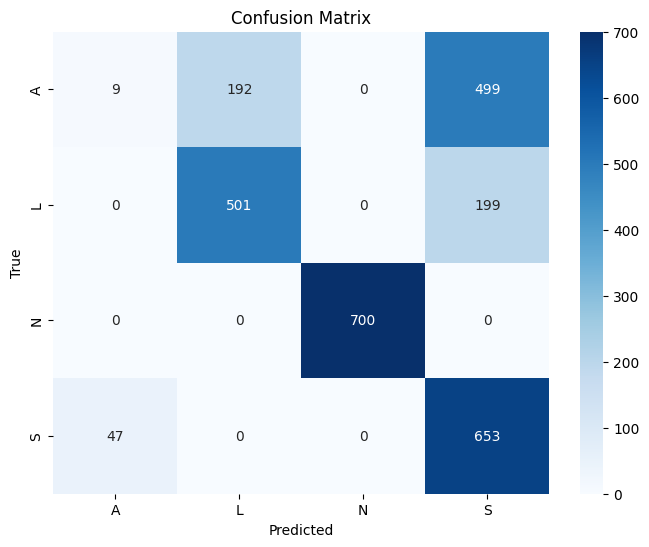

In [38]:
# Class labels
class_labels = list(test_gen.class_indices.keys())

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()



In [39]:
# Classification Report
report = classification_report(y_true, y_pred, target_names=class_labels)
print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

           A       0.16      0.01      0.02       700
           L       0.72      0.72      0.72       700
           N       1.00      1.00      1.00       700
           S       0.48      0.93      0.64       700

    accuracy                           0.67      2800
   macro avg       0.59      0.67      0.59      2800
weighted avg       0.59      0.67      0.59      2800



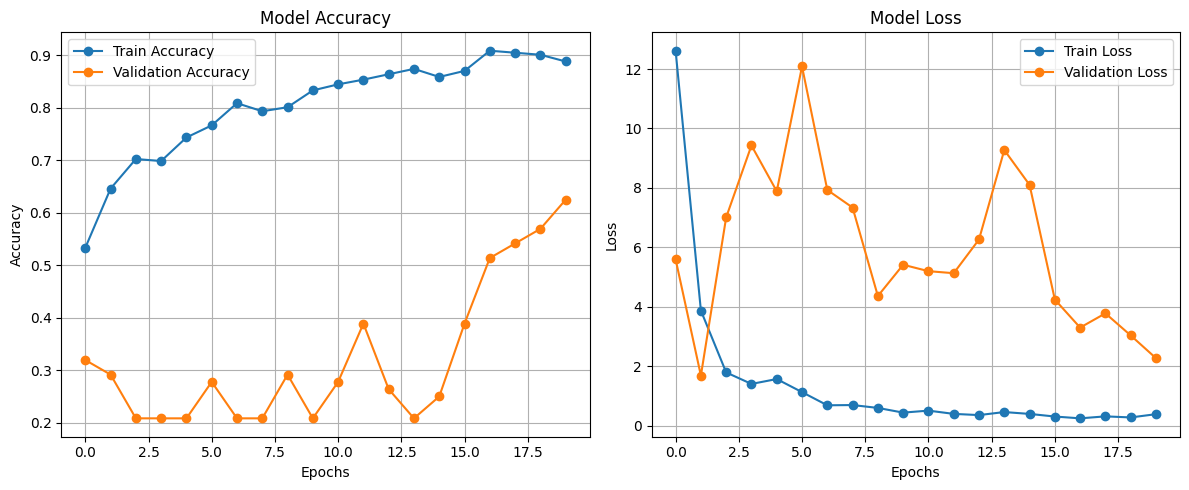

In [40]:

plt.figure(figsize=(12,5))

# ---------------------------
# Accuracy plot
# ---------------------------
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# ---------------------------
# Loss plot
# ---------------------------
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [41]:
# Overall Training accuracy
train_loss, train_accuracy = model.evaluate(train_gen, verbose=1)
print(f"Training Accuracy: {train_accuracy*100:.2f}%")


25/25 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.8601 - loss: 0.4963
Training Accuracy: 87.31%


In [42]:
# overall validation accuracy
val_loss, val_accuracy = model.evaluate(val_gen, verbose=1)
print(f"Validation Accuracy: {val_accuracy*100:.2f}%")


3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 656ms/step - accuracy: 0.6055 - loss: 2.1128
Validation Accuracy: 62.50%
